In [25]:
from sklearn.datasets import make_classification
import numpy as np
x,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                          n_classes=2, n_clusters_per_class=1, random_state=41, hypercube = False, class_sep = 20)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

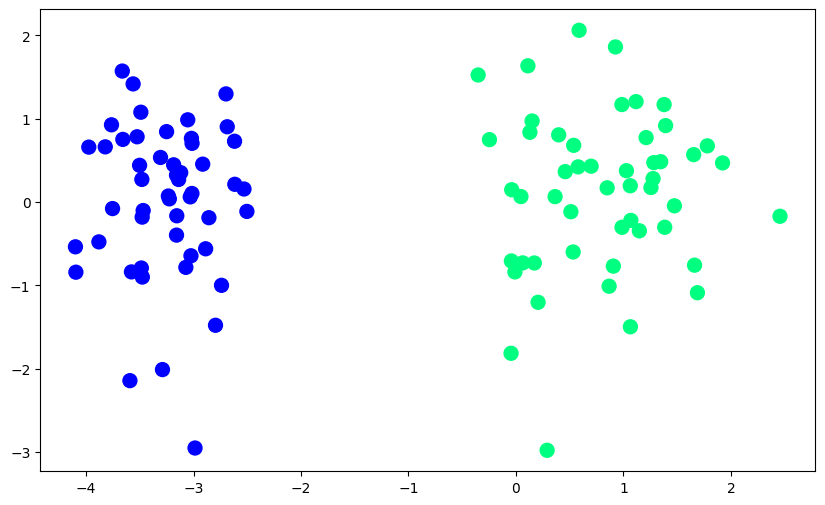

AttributeError: 'NoneType' object has no attribute 'remove_callback'

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(x[:,0], x[:,1],c=y, cmap='winter',s=100)

In [27]:
%matplotlib inline

In [32]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty = None, solver='sag')
lor.fit(x,y)

# penalty is none that means we arent applying any regularization

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [33]:
print(lor.coef_)
print(lor.intercept_)

[[4.79618677 0.20317962]]
[5.77520601]


In [34]:
m1 = -lor.coef_[0][0]/lor.coef_[0][1]
c1 = -lor.intercept_[0]/lor.coef_[0][1]

x_input = np.linspace(-3,3,100)
y_input = m1*x_input + c1

In [38]:
# what we will be applying is batch gradient descent
# u can also use mini batch gd, or sgd too

def gd(x,y):

  x = np.insert(x,0,1,axis=1)
  weights = np.ones(x.shape[1])
  lr = 0.5

  for i in range(3000):
    y_hat = sigmoid(np.dot(x,weights))
    weights = weights + lr*(np.dot((y-y_hat),x) / x.shape[0])

  return weights[1:], weights[0]

In [36]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [39]:
coef_, intercept_ = gd(x,y)

In [41]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/ coef_[1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m* x_input1+b


(-3.0, 2.0)

<IPython.core.display.Javascript object>

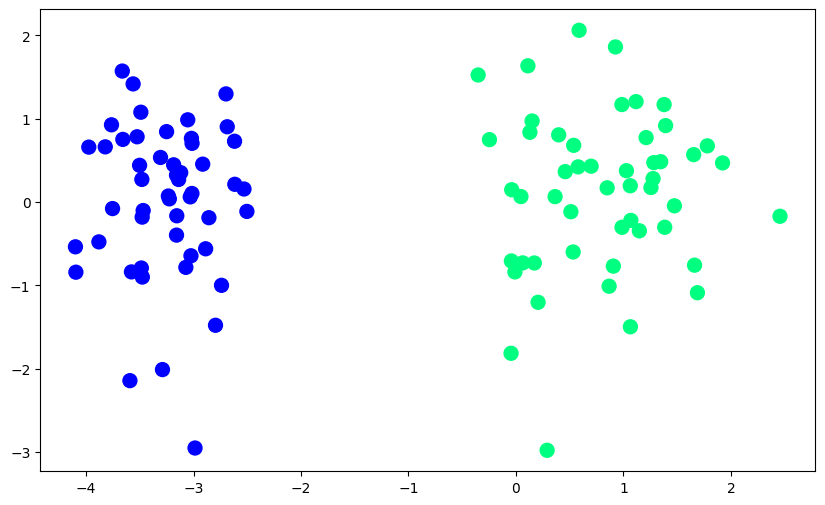

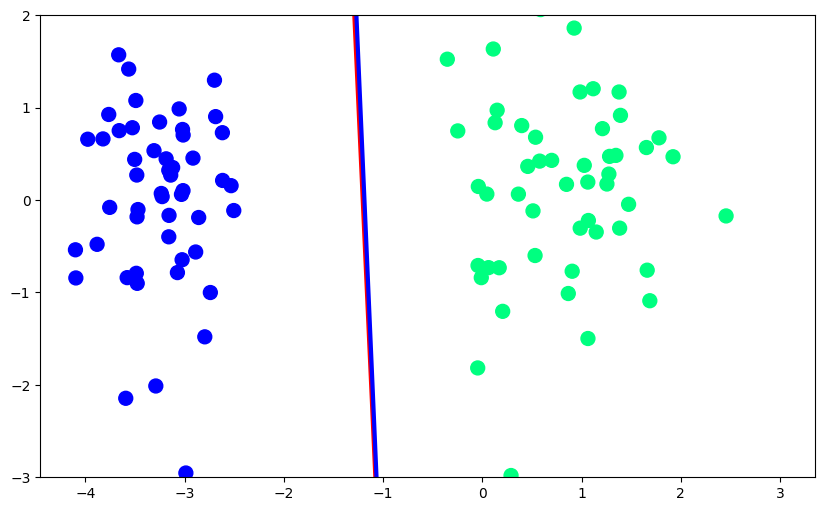

In [42]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red',linewidth=3)
plt.plot(x_input1, y_input1, color='blue',linewidth=3)
plt.scatter(x[:,0], x[:,1],c=y, cmap='winter',s=100)
plt.ylim(-3,2)